In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

import scipy as sp

In [12]:
def tdoa(r_target, r_ref, r_sens):
    return np.linalg.norm(r_ref - r_target) - np.linalg.norm(r_sens - r_target)

def fdoa(r_target, v_target, r_ref, r_sens):
    return np.dot(r_ref - r_target, v_target) / np.linalg.norm(r_ref - r_target)\
         - np.dot(r_sens - r_target, v_target) / np.linalg.norm(r_sens - r_target)

In [13]:
r_target = np.array([1, 1])
v_target = np.array([1, 0])
r_ref = np.array([0, 0])
r_sens = np.array([0, 1])

print(tdoa(r_target, r_ref, r_sens))
print(fdoa(r_target, v_target, r_ref, r_sens))

0.41421356237309515
0.29289321881345254


In [19]:
r_ref = np.array([-1, -1])
r_1 = np.array([-1, 1])
r_2 = np.array([1, -1])

r_target = np.array([0.1, -.2])
v_target = np.array([1, 1])

rs = np.array([r_ref, r_1, r_2, r_target])

for r in rs[1:-1]:
  print(tdoa(r_target, r_ref, r))
  print(fdoa(r_target, v_target, r_ref, r))
  print("\n")

-0.2677350087364263
-1.4583372936616297


0.15598759299431486
-1.4799532618319746




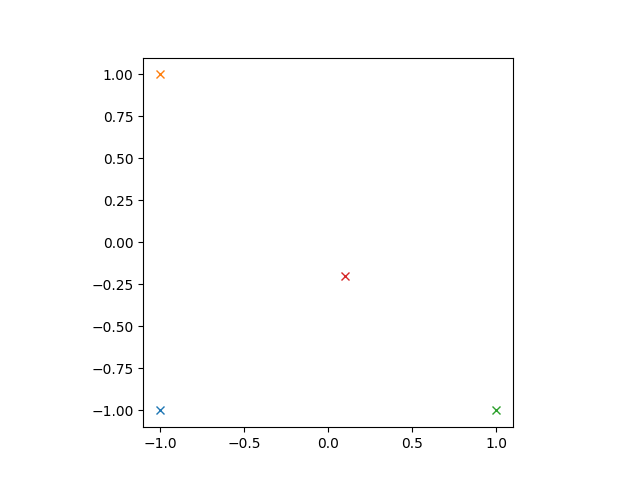

In [18]:
fig = plt.figure()
ax = fig.add_subplot(111)

for r in rs:
  ax.plot(r[0], r[1], 'x')
  
ax.set_aspect('equal')

In [21]:
import scipy

In [35]:
tdoa1 = tdoa(r_target, r_ref, r_1)
tdoa2 = tdoa(r_target, r_ref, r_2)

fdoa1 = fdoa(r_target, v_target, r_ref, r_1)
fdoa2 = fdoa(r_target, v_target, r_ref, r_2)
result = scipy.optimize.minimize(lambda x: (tdoa(x, r_ref, r_1) - tdoa1)**2 + (tdoa(x, r_ref, r_2) - tdoa2)**2, [0, 0])
print(result.x)
result = scipy.optimize.minimize(lambda x: (fdoa(x, v_target, r_ref, r_1) - fdoa1)**2 + (fdoa(x, v_target, r_ref, r_2) - fdoa2)**2, [0, 0])
print(result.x)

[ 0.10000019 -0.19999989]
[ 0.10003352 -0.20003959]
